In [1]:
from rocketpy import Environment, SolidMotor, Rocket, Flight, Plate

In [2]:
env = Environment(latitude=32.990254, longitude=-106.974998, elevation=1400)

In [3]:
import datetime

tomorrow = datetime.date.today() + datetime.timedelta(days=1)

env.set_date(
    (tomorrow.year, tomorrow.month, tomorrow.day, 12)
)  # Hour given in UTC time

In [4]:
env.set_atmospheric_model(type="Forecast", file="GFS")

In [5]:
Pro75M1670 = SolidMotor(
    thrust_source="/Users/aitorpg/Documents/RocketPy/data/motors/cesaroni/Cesaroni_M1670.eng",
    dry_mass=1.815,
    dry_inertia=(0.125, 0.125, 0.002),
    nozzle_radius=33 / 1000,
    grain_number=5,
    grain_density=1815,
    grain_outer_radius=33 / 1000,
    grain_initial_inner_radius=15 / 1000,
    grain_initial_height=120 / 1000,
    grain_separation=5 / 1000,
    grains_center_of_mass_position=0.397,
    center_of_dry_mass_position=0.317,
    nozzle_position=0,
    burn_time=3.9,
    throat_radius=11 / 1000,
    coordinate_system_orientation="nozzle_to_combustion_chamber",
)

Nozzle Details
Nozzle Radius: 0.033 m
Nozzle Throat Radius: 0.011 m

Grain Details
Number of Grains: 5
Grain Spacing: 0.005 m
Grain Density: 1815 kg/m3
Grain Outer Radius: 0.033 m
Grain Inner Radius: 0.015 m
Grain Height: 0.12 m
Grain Volume: 0.000 m3
Grain Mass: 0.591 kg

Motor Details
Total Burning Time: 3.9 s
Total Propellant Mass: 2.956 kg
Structural Mass Ratio: 0.380
Average Propellant Exhaust Velocity: 2038.745 m/s
Average Thrust: 1545.218 N
Maximum Thrust: 2200.0 N at 0.15 s after ignition.
Total Impulse: 6026.350 Ns



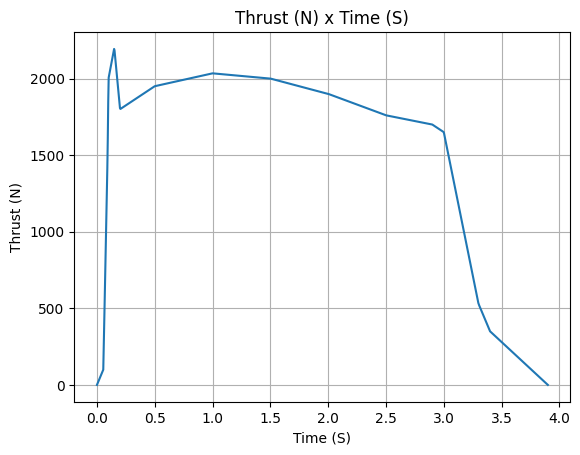

In [6]:
Pro75M1670.info()

In [7]:
calisto = Rocket(
    radius=127 / 2000,
    mass=14.426,
    inertia=(6.321, 6.321, 0.034),
    power_off_drag="/Users/aitorpg/Documents/RocketPy/data/rockets/calisto/powerOffDragCurve.csv",
    power_on_drag="/Users/aitorpg/Documents/RocketPy/data/rockets/calisto/powerOnDragCurve.csv",
    center_of_mass_without_motor=0,
    coordinate_system_orientation="tail_to_nose",
)

In [8]:
calisto.add_motor(Pro75M1670, position=-1.255)

In [9]:
rail_buttons = calisto.set_rail_buttons(
    upper_button_position=0.0818,
    lower_button_position=-0.6182,
    angular_position=45,
)

self.top_radius: 0.0635, bottom radius 0.0435

small_circular_plate representation: 


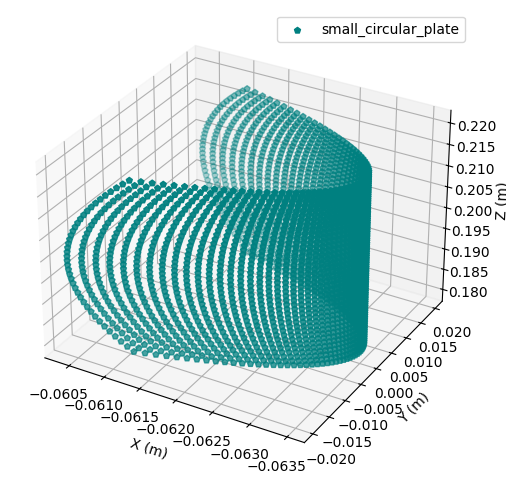

In [10]:
nose_cone = calisto.add_nose(
    length=0.55829, kind="von karman", position=1.278
)

fin_set = calisto.add_trapezoidal_fins(
    n=4,
    root_chord=0.120,
    tip_chord=0.060,
    span=0.110,
    position=-1.04956,
    cant_angle=0.5,
    airfoil=("/Users/aitorpg/Documents/RocketPy/data/airfoils/NACA0012-radians.txt","radians"),
)

tail = calisto.add_tail(
    top_radius=0.0635, bottom_radius=0.0435, length=0.060, position=-1.194656
)

small_plate = Plate(
        shape="circular",
        dimensions=0.04,
        material="carbon_steel",
        thickness=0.0002,
        z_points=40,
        angular_points=70,
        name="small_circular_plate",
    )
calisto.add_plate(small_plate, position=90, height= 0.2)
small_plate.plots.draw_3d(color = 'teal', marker = 'p')


In [11]:
for i in range(len(small_plate.points)):
    coordinates = small_plate.points[i]
    x = coordinates[0]
    print(f'x_bacs frame: {float(x)}')

x_bacs frame: -0.061152404700983966
x_bacs frame: -0.06128573970252312
x_bacs frame: -0.061415243874907106
x_bacs frame: -0.061540909123131086
x_bacs frame: -0.06166272759215245
x_bacs frame: -0.061780691667381815
x_bacs frame: -0.06189479397515901
x_bacs frame: -0.06200502738321394
x_bacs frame: -0.062111385001112476
x_bacs frame: -0.06221386018068709
x_bacs frame: -0.062312446516452485
x_bacs frame: -0.06240713784600593
x_bacs frame: -0.0624979282504125
x_bacs frame: -0.06258481205457499
x_bacs frame: -0.06266778382758875
x_bacs frame: -0.06274683838308108
x_bacs frame: -0.06282197077953545
x_bacs frame: -0.06289317632060036
x_bacs frame: -0.06296045055538294
x_bacs frame: -0.06302378927872711
x_bacs frame: -0.06308318853147649
x_bacs frame: -0.06313864460072183
x_bacs frame: -0.06319015402003314
x_bacs frame: -0.06323771356967632
x_bacs frame: -0.06328132027681445
x_bacs frame: -0.06332097141569364
x_bacs frame: -0.06335666450781333
x_bacs frame: -0.06338839732208128
x_bacs frame: -

In [12]:
main = calisto.add_parachute(
    name="main",
    cd_s=10.0,
    trigger=800,      # ejection altitude in meters
    sampling_rate=105,
    lag=1.5,
    noise=(0, 8.3, 0.5),
    radius=1.5,
    height=1.5,
    porosity=0.0432,
)

drogue = calisto.add_parachute(
    name="drogue",
    cd_s=1.0,
    trigger="apogee",  # ejection at apogee
    sampling_rate=105,
    lag=1.5,
    noise=(0, 8.3, 0.5),
    radius=1.5,
    height=1.5,
    porosity=0.0432,
)

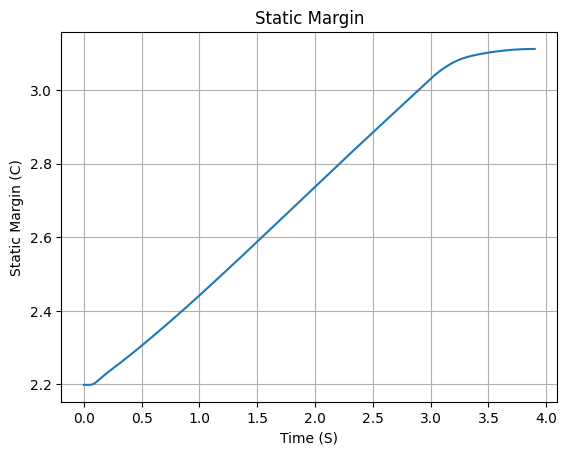

In [13]:
calisto.plots.static_margin()

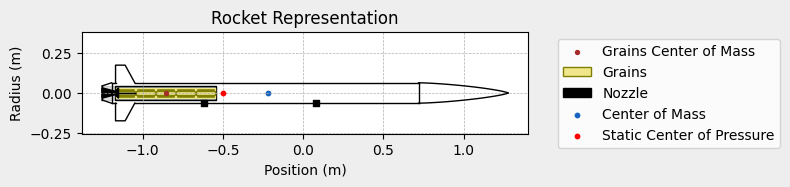

In [14]:
calisto.draw()

In [15]:
test_flight = Flight(
    rocket=calisto, environment=env, rail_length=5.2, inclination=85, heading=0, verbose = True
    )

Current Simulation Time: 292.3843 s
>>> Simulation Completed at Time: 291.5363 s



Initial Conditions

Initial time: 0.000 s
Position - x: 0.00 m | y: 0.00 m | z: 1471.47 m
Velocity - Vx: 0.00 m/s | Vy: 0.00 m/s | Vz: 0.00 m/s
Attitude (quaternions) - e0: 0.923 | e1: -0.040 | e2: 0.017 | e3: 0.382
Euler Angles - Spin φ : 45.00° | Nutation θ: -5.00° | Precession ψ: 0.00°
Angular Velocity - ω1: 0.00 rad/s | ω2: 0.00 rad/s | ω3: 0.00 rad/s
Initial Stability Margin: 2.199 c


Surface Wind Conditions

Frontal Surface Wind Speed: -3.30 m/s
Lateral Surface Wind Speed: -0.46 m/s


Launch Rail

Launch Rail Length: 5.2 m
Launch Rail Inclination: 85.00°
Launch Rail Heading: 0.00°


Rail Departure State

Rail Departure Time: 0.368 s
Rail Departure Velocity: 26.207 m/s
Rail Departure Stability Margin: 2.276 c
Rail Departure Angle of Attack: 7.155°
Rail Departure Thrust-Weight Ratio: 10.152
Rail Departure Reynolds Number: 1.815e+05


Burn out State

Burn out time: 3.900 s
Altitude at burn out: 2126.364 m (ASL) | 654.898 m (AGL)
Rocket speed at burn out: 281.571 m/s
Freestream vel

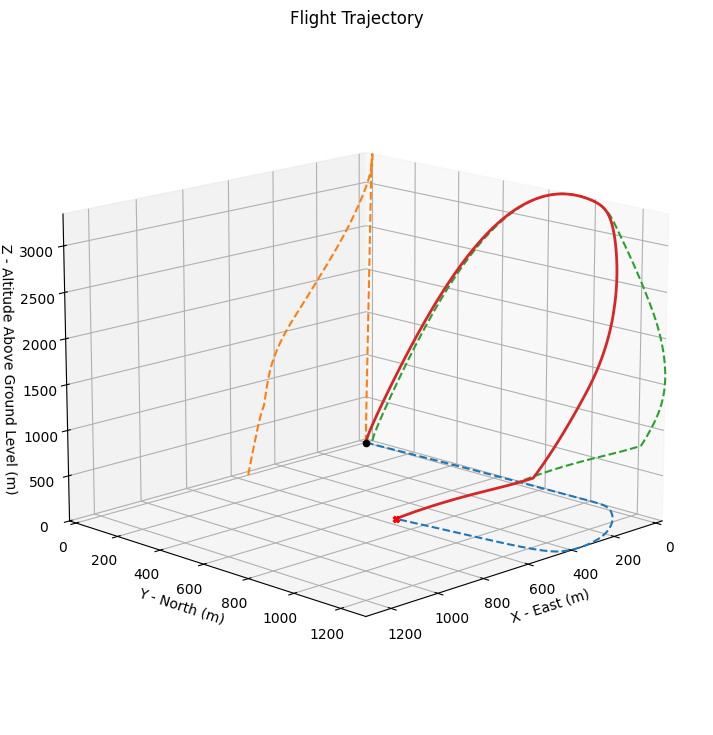



Trajectory Kinematic Plots



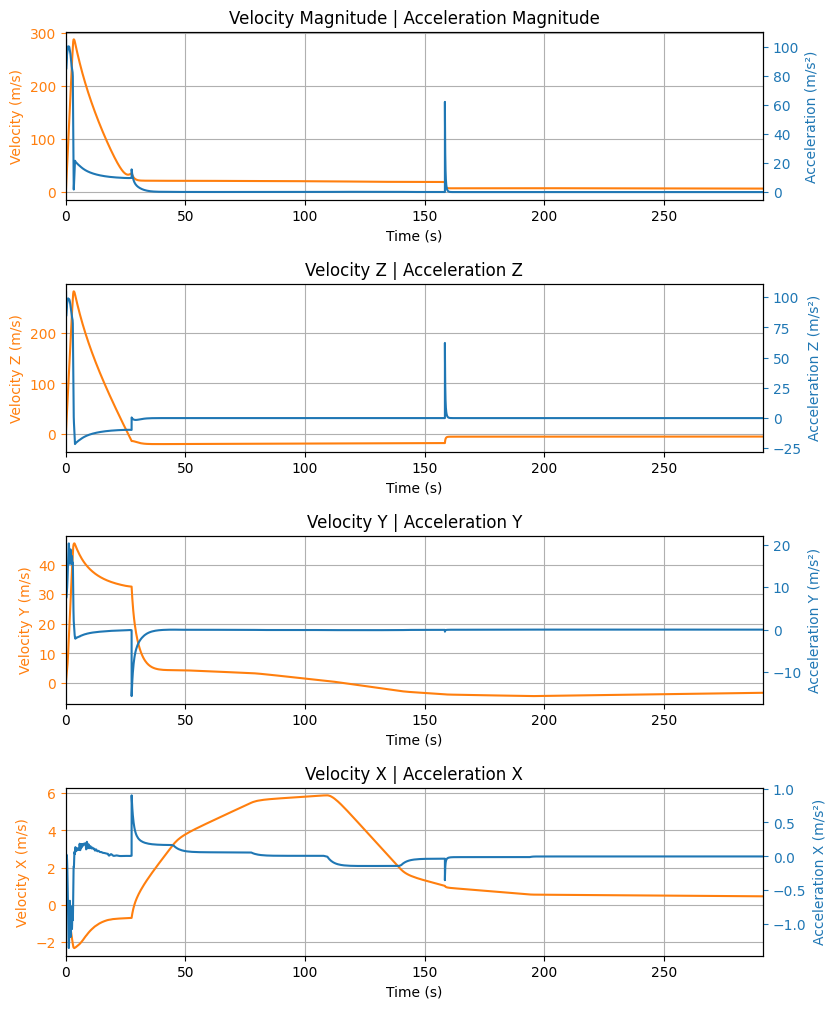



Angular Position Plots



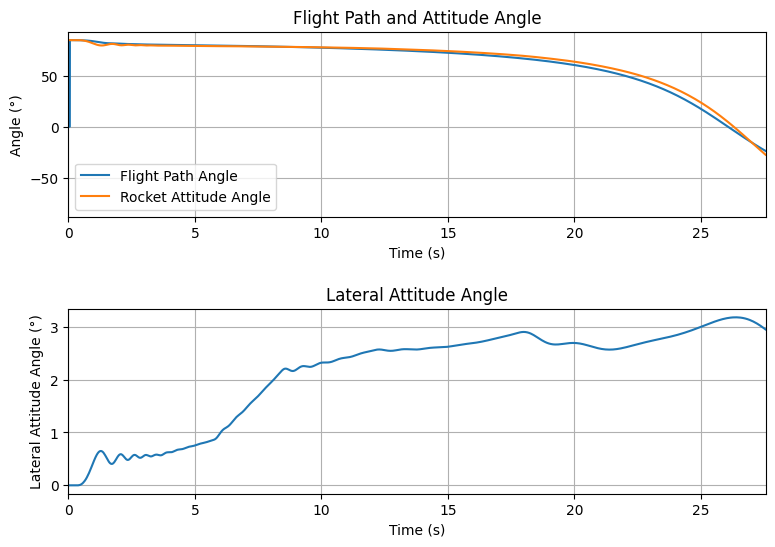



Path, Attitude and Lateral Attitude Angle Plots



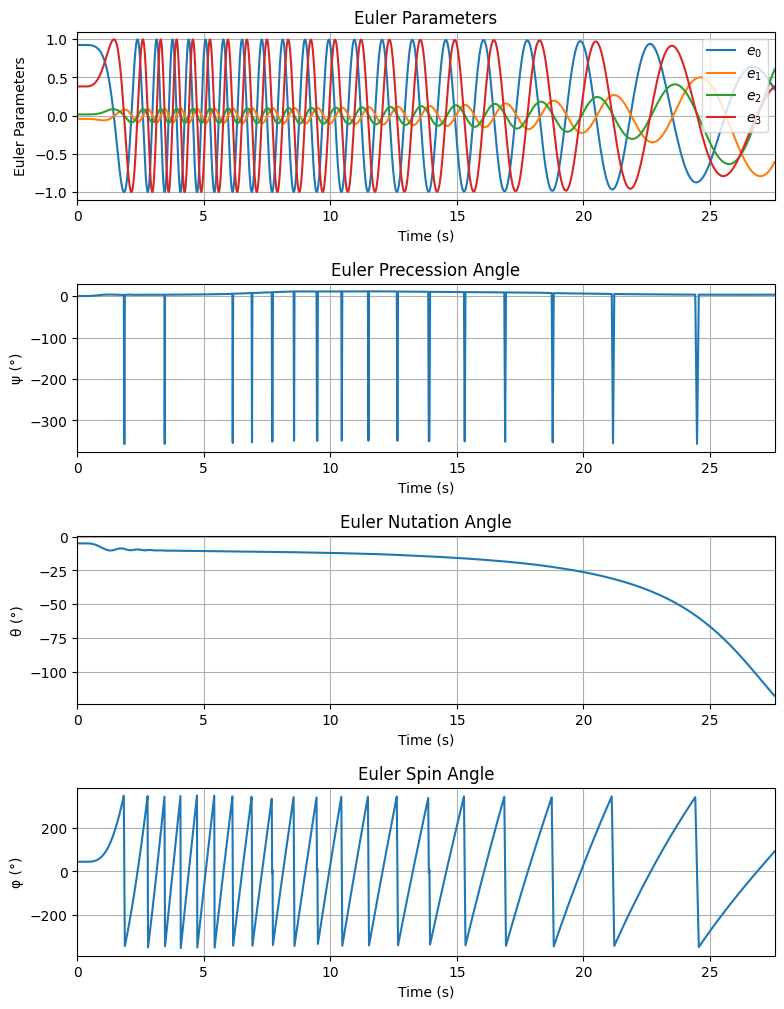



Trajectory Angular Velocity and Acceleration Plots



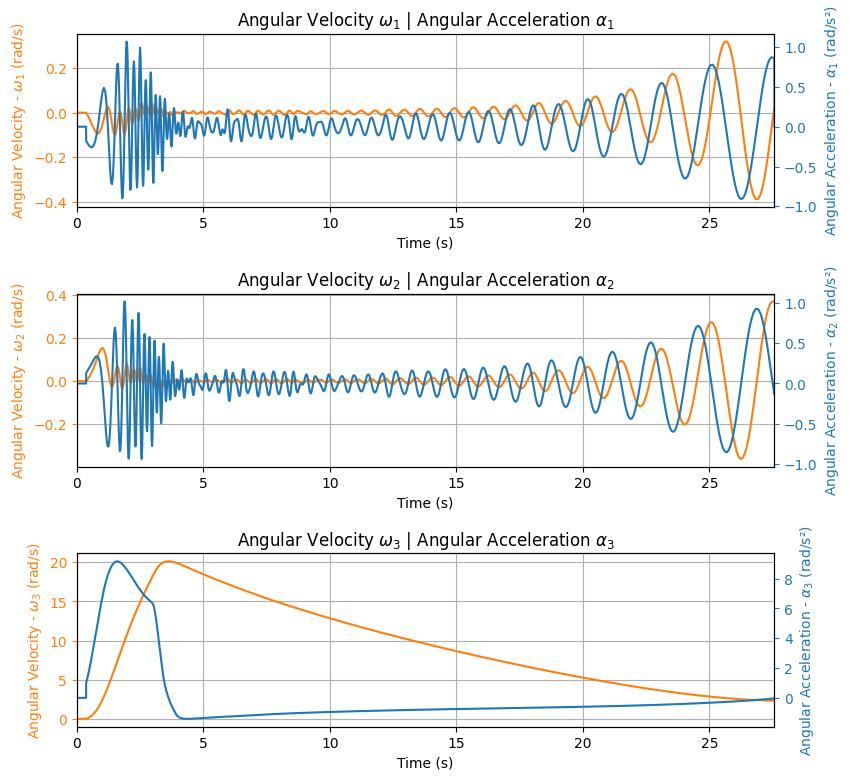



Aerodynamic Forces Plots



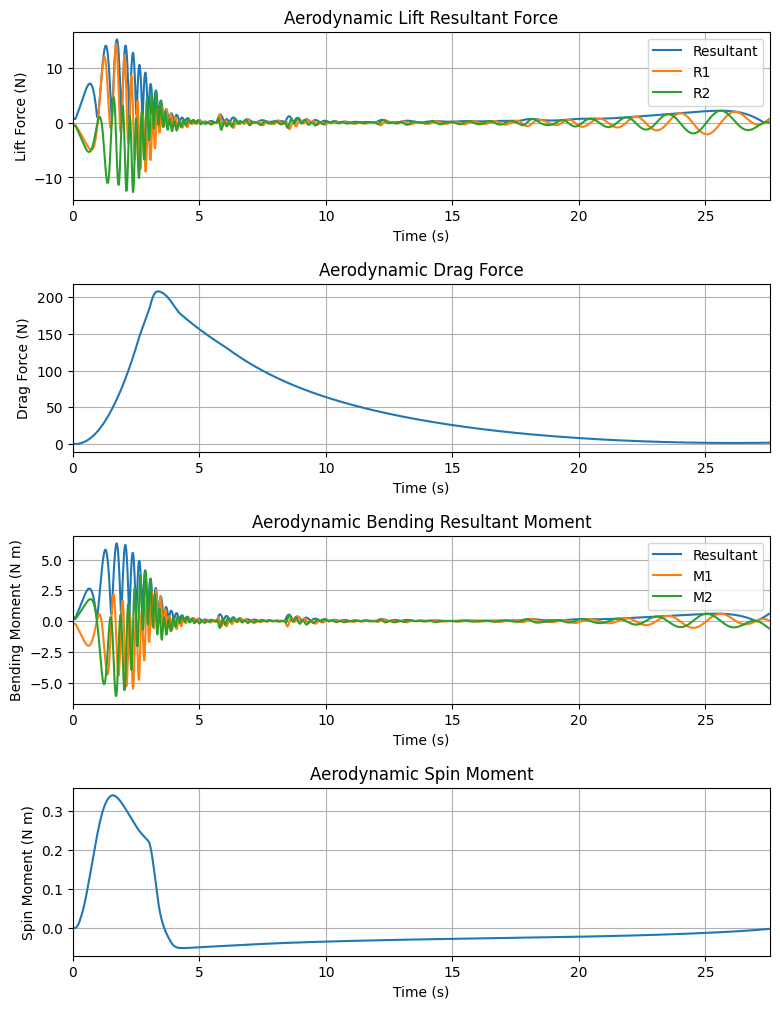

Rail button height not defined. Skipping bending moment plots.




Rail Buttons Bending Moments Plots



Rail Buttons Forces Plots



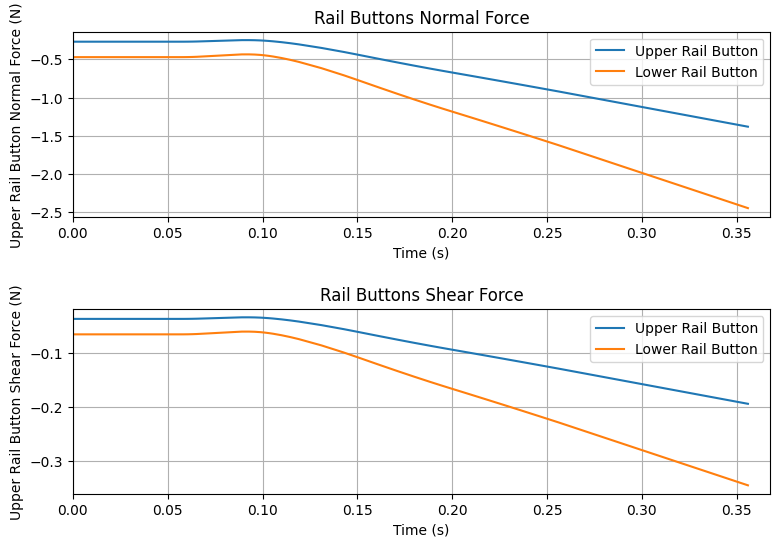



Trajectory Energy Plots



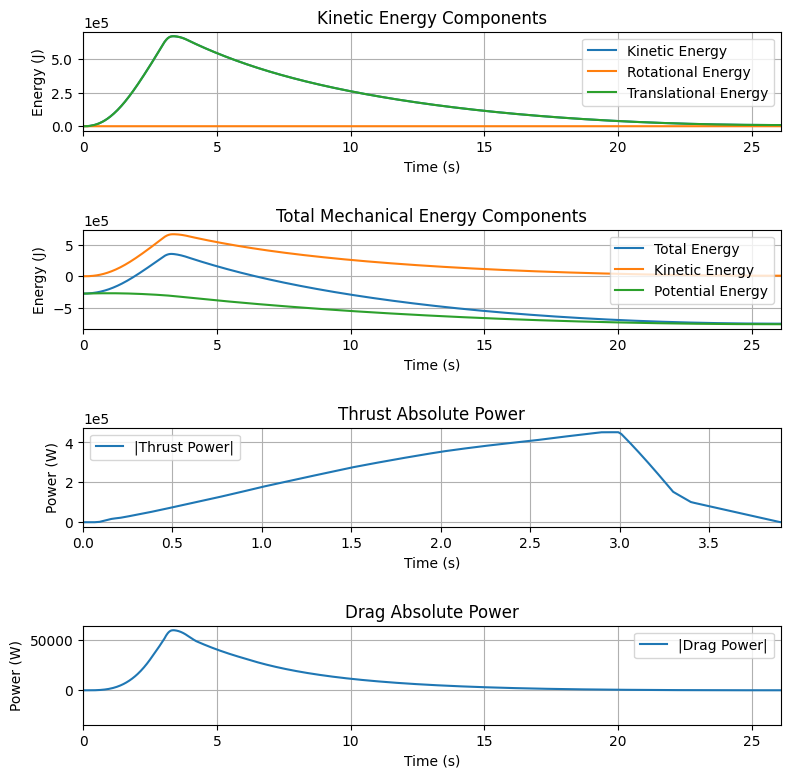



Trajectory Fluid Mechanics Plots



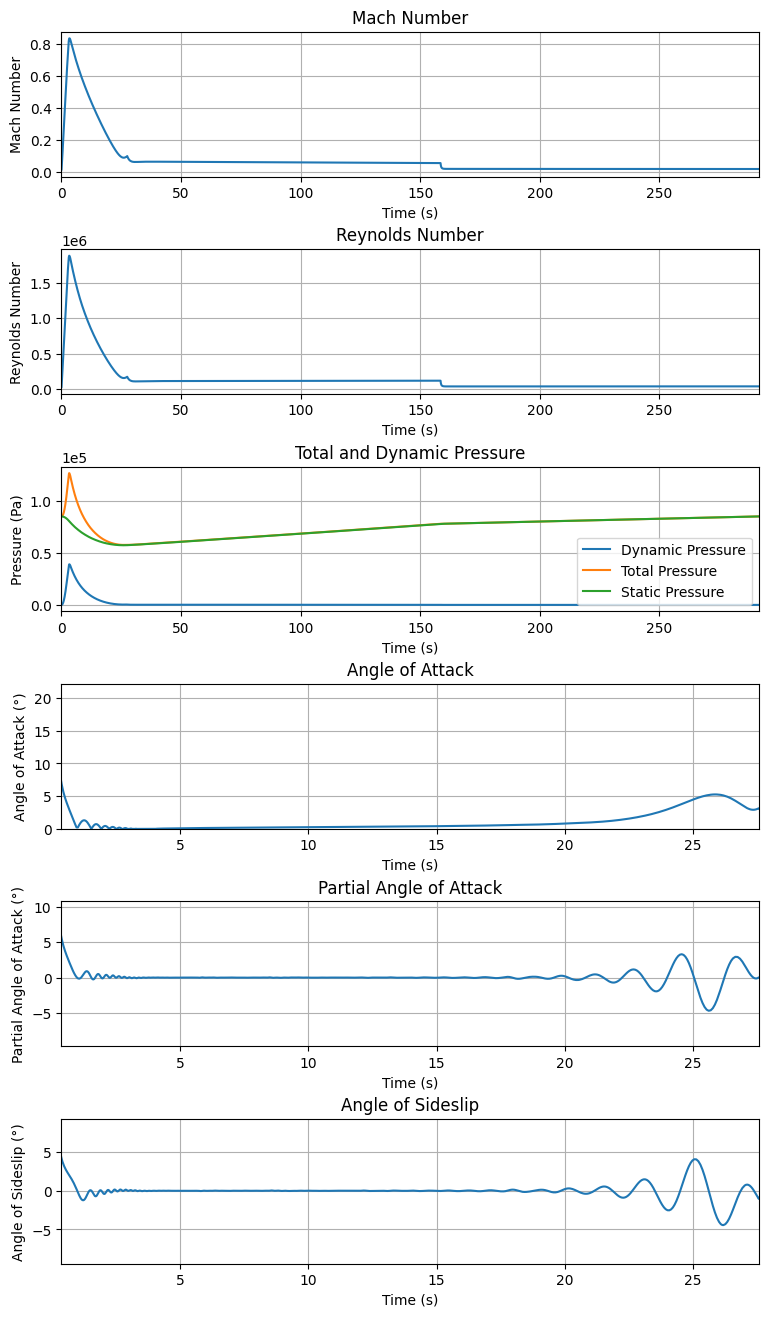



Trajectory Stability and Control Plots



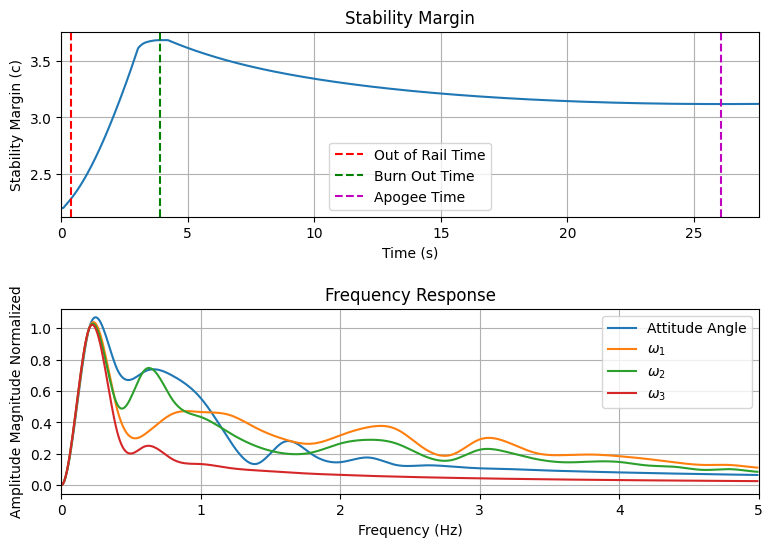



Rocket and Parachute Pressure Plots



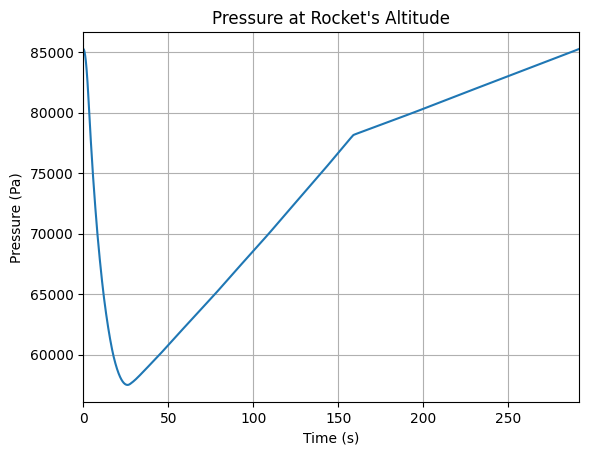

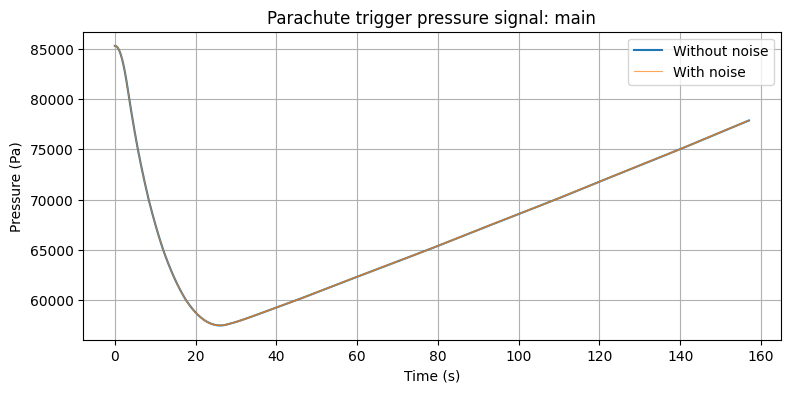

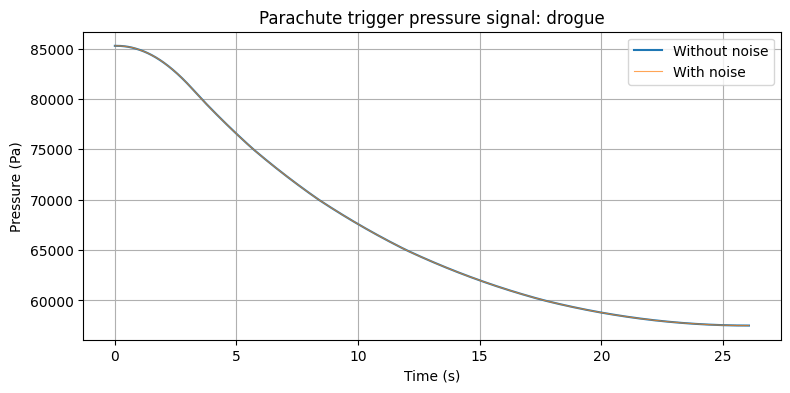

In [16]:
test_flight.all_info()